In [ ]:
# Pull just the code (src/, notebooks/, report/), skip their committed dataset zip
!git clone --filter=blob:none --sparse https://github.com/hackysoham/ASTRA.git
%cd ASTRA
!git sparse-checkout set src notebooks report tests
!ls src/  # confirm dataset.py, models.py, losses.py, train.py, utils.py, latent_extract.py are there

fatal: destination path 'ASTRA' already exists and is not an empty directory.
/content/ASTRA
dataset.py   isolation_engine.py  latent_utils.py     models.py    utils.py
heatmaps.py  isolation_forest.py  losses.py	      __pycache__
__init__.py  latent_extract.py	  metadata_fusion.py  train.py


In [ ]:
# Mount your own Drive (your existing data, untouched from before)
from google.colab import drive
drive.mount('/content/drive')

DRIVE_FOLDER = '/content/drive/MyDrive/nssc2026'
!unzip -q -n {DRIVE_FOLDER}/images.zip -d /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IMAGE_DIR = '/content/images'
METADATA_PATH = f'{DRIVE_FOLDER}/source_image_metadata.csv'



# Phase 1: Deep Latent Compression (30 Marks)

**Team Astra** | NSSC 2026 | IIT Kharagpur  
**Lead:**

---

## Objectives
1. Architect a Convolutional / Variational Autoencoder **from scratch** in PyTorch
2. Compress each 227×227 grayscale image into a fixed-length 1D latent vector
3. Design a combined reconstruction loss (MSE + SSIM + KL)
4. Train all 5 architecture versions (v1–v5)
5. Visualize latent space via t-SNE and UMAP

### Key Constraints
- **No pretrained weights** — all models built from scratch
- **No transfer learning** — no VGG, ResNet, or pretrained feature extractors
- **Exact output shape** — decoder must produce exactly (B, 1, 227, 227)




In [ ]:
# ─── System Setup ─────────────────────────────────────────────────────
import sys
import os

# Ensure project root is in path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Configuration
IMAGE_DIR = os.path.join(PROJECT_ROOT, 'data', 'images')
METADATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'source_image_metadata.csv')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'models')
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'plots')
LATENT_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'latent_vectors')

print(f'Project root: {PROJECT_ROOT}')
print(f'Image dir: {IMAGE_DIR}')

Project root: /content
Image dir: /content/data/images


In [ ]:
IMAGE_DIR = '/content/images'
METADATA_PATH = '/content/drive/MyDrive/nssc2026/crop_metadata_index.csv'
print('Image dir (overridden):', IMAGE_DIR)
print('Metadata path (overridden):', METADATA_PATH)

Image dir (overridden): /content/images
Metadata path (overridden): /content/drive/MyDrive/nssc2026/crop_metadata_index.csv


In [ ]:
import os
print(len(os.listdir('/content/images')), 'files found')
print(os.listdir('/content/images')[:3])

10422 files found
['sample_07425.jpg', 'sample_06761.jpg', 'sample_03312.jpg']


In [ ]:
# ─── Imports ──────────────────────────────────────────────────────────
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.utils import set_seed, get_device, ensure_dirs
from src.dataset import MarsHiRISEDataset, create_dataloaders
from src.models import get_model, MODEL_REGISTRY
from src.losses import CombinedLoss
from src.train import train_model
from src.latent_utils import extract_latents, save_latents, plot_tsne, plot_umap
from src.utils import plot_loss_curves, plot_reconstructions

# Reproducibility
set_seed(42)
device = get_device()
ensure_dirs()

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

[Device] Using CUDA: Tesla T4
[Setup] Output directories created.
PyTorch version: 2.11.0+cu128
CUDA available: True


## 1.1 Data Loading & Exploration

In [ ]:
# Create DataLoaders
train_loader, val_loader, full_loader = create_dataloaders(
    image_dir=IMAGE_DIR,
    metadata_csv=METADATA_PATH,
    batch_size=32,
    val_split=0.1,
    num_workers=4,
    seed=42,
)

# Verify a sample batch
sample_batch = next(iter(train_loader))
images, filenames, *_ = sample_batch
print(f'Batch shape: {images.shape}')  # Expected: (32, 1, 227, 227)
print(f'Value range: [{images.min():.3f}, {images.max():.3f}]')
print(f'Sample filenames: {filenames[:3]}')

[Dataset] Loaded 10422 crops from /content/images (CSV: crop_metadata_index.csv)
[Split] Train: 9380 | Val: 1042


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Batch shape: torch.Size([32, 1, 227, 227])
Value range: [0.000, 1.000]
Sample filenames: ('sample_09435.jpg', 'sample_08792.jpg', 'sample_01745.jpg')


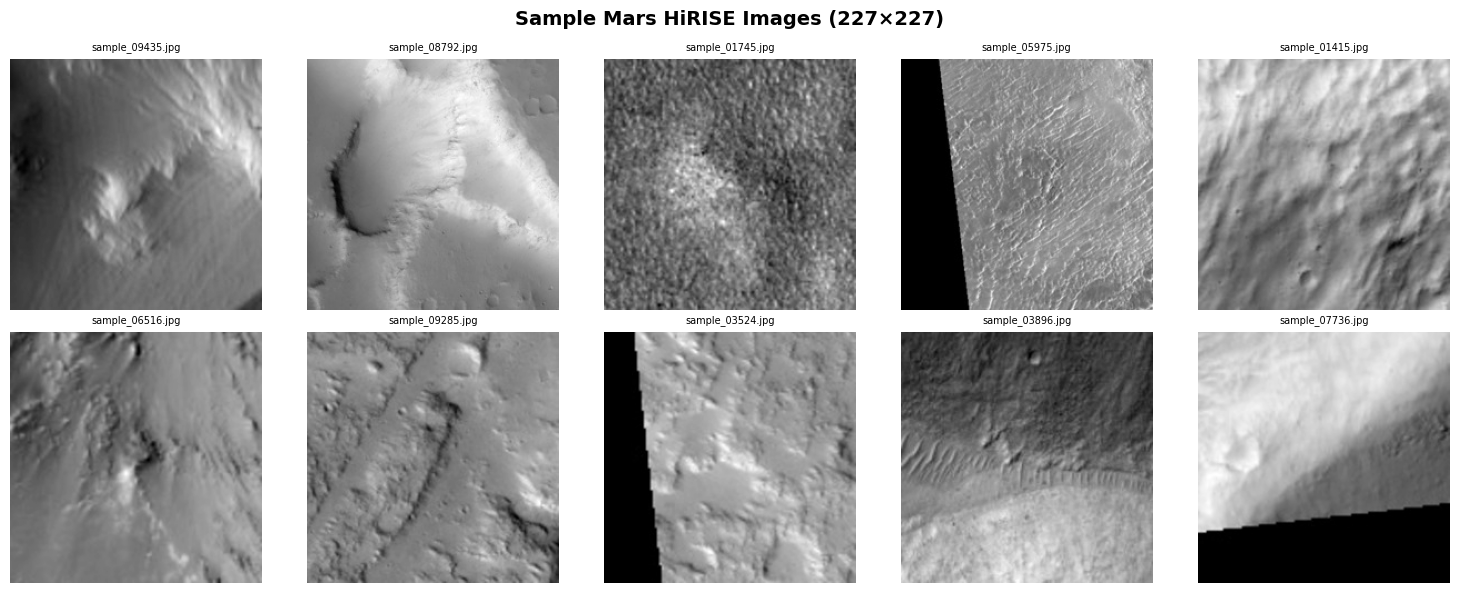

In [ ]:
# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    if i < images.shape[0]:
        ax.imshow(images[i].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        ax.set_title(filenames[i][:20], fontsize=7)
    ax.axis('off')
fig.suptitle('Sample Mars HiRISE Images (227×227)', fontsize=14, fontweight='bold')
plt.tight_layout()
#plt.savefig(os.path.join(PLOTS_DIR, 'sample_images.png'), dpi=150)
plt.show()

## 1.2 Architecture Verification

Before training, verify that all 5 model versions produce the exact output shape `(B, 1, 227, 227)`.

In [ ]:
# Shape verification for all 5 versions
test_input = torch.randn(2, 1, 227, 227)
print('Architecture Shape Verification')
print('=' * 60)

for version_name, model_class in MODEL_REGISTRY.items():
    model = model_class()
    model.eval()
    with torch.no_grad():
        output = model(test_input)
        if isinstance(output, tuple):
            out_shape = output[0].shape
        else:
            out_shape = output.shape

    n_params = sum(p.numel() for p in model.parameters())
    status = '✓' if out_shape == (2, 1, 227, 227) else '✗ MISMATCH'
    print(f'  {version_name.upper():4s} | Output: {str(out_shape):20s} | '
          f'Params: {n_params:>12,} | {status}')

    assert out_shape == (2, 1, 227, 227), \
        f'{version_name} shape mismatch: {out_shape}'

print('\n✓ All models verified: exact (B, 1, 227, 227) output')

Architecture Shape Verification
  V1   | Output: torch.Size([2, 1, 227, 227]) | Params:   14,273,345 | ✓
  V2   | Output: torch.Size([2, 1, 227, 227]) | Params:   14,273,345 | ✓
  V3   | Output: torch.Size([2, 1, 227, 227]) | Params:   18,446,401 | ✓
  V4   | Output: torch.Size([2, 1, 227, 227]) | Params:   24,869,185 | ✓
  V5   | Output: torch.Size([2, 1, 227, 227]) | Params:   25,557,825 | ✓

✓ All models verified: exact (B, 1, 227, 227) output


## 1.3 Training All 5 Versions

### Training Configuration

| Version | Type | Latent | α (MSE) | β (SSIM) | γ (KL) | β-annealing |
|---------|------|--------|---------|----------|--------|-------------|
| v1 | CAE | 128 | 1.0 | 0.0 | 0.0 | No |
| v2 | CAE+BN | 128 | 0.5 | 0.5 | 0.0 | No |
| v3 | VAE | 128 | 0.5 | 0.5 | 0.001 | No |
| v4 | VAE+Skip | 256 | 0.5 | 0.5 | 0.001 | No |
| v5 | β-VAE+Skip | 256 | 0.5 | 0.5 | 0.0 | Yes (max=0.005) |

In [ ]:
# Training configuration for all 5 versions
TRAIN_CONFIGS = {
    'v1': dict(
        epochs=50, lr=1e-3, alpha=1.0, beta=0.0, gamma=0.0,
        patience=10, beta_annealing=False,
    ),
    'v2': dict(
        epochs=50, lr=1e-3, alpha=0.5, beta=0.5, gamma=0.0,
        patience=10, beta_annealing=False,
    ),
    'v3': dict(
        epochs=50, lr=1e-3, alpha=0.5, beta=0.5, gamma=0.001,
        patience=10, beta_annealing=False,
    ),
    'v4': dict(
        epochs=50, lr=1e-3, alpha=0.5, beta=0.5, gamma=0.001,
        patience=10, beta_annealing=False,
    ),
    'v5': dict(
        epochs=50, lr=1e-3, alpha=0.5, beta=0.5, gamma=0.0,
        patience=10, beta_annealing=True, beta_max=0.005,
    ),
}

# Storage for all training histories
all_histories = {}


██████████████████████████████████████████████████████████████████████
 TRAINING v1: Baseline Convolutional Autoencoder
██████████████████████████████████████████████████████████████████████
[Model] V1 | AEv1 | latent=128 | params=14,273,345 | VAE=False

 Training V1 | Epochs: 50 | LR: 0.001
 Loss weights — α(MSE): 1.0 | β(SSIM): 0.0 | γ(KL): 0.0
 β-annealing: False (max=0.001)
 Device: cuda | Patience: 10



  Train:   0%|          | 0/293 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Epoch   1/50 │ Train: 0.012657 │ Val: 0.009628 │ MSE: 0.009628 │ SSIM: 0.485801
[Checkpoint] Saved → /content/outputs/models/best_v1.pth (epoch=1, loss=0.009628)


  Epoch   2/50 │ Train: 0.008027 │ Val: 0.007405 │ MSE: 0.007405 │ SSIM: 0.471456
[Checkpoint] Saved → /content/outputs/models/best_v1.pth (epoch=2, loss=0.007405)


  Epoch   3/50 │ Train: 0.007113 │ Val: 0.006925 │ MSE: 0.006925 │ SSIM: 0.467336
[Checkpoint] Saved → /content/outputs/models/best_v1.pth (epoch=3, loss=0.006925)


...

  Epoch  46/50 │ Train: 0.004688 │ Val: 0.004696 │ MSE: 0.004696 │ SSIM: 0.424268


  Epoch  47/50 │ Train: 0.004690 │ Val: 0.004713 │ MSE: 0.004713 │ SSIM: 0.424191


  Epoch  48/50 │ Train: 0.004690 │ Val: 0.004708 │ MSE: 0.004708 │ SSIM: 0.424883


  Epoch  49/50 │ Train: 0.004624 │ Val: 0.004646 │ MSE: 0.004646 │ SSIM: 0.422971
[Checkpoint] Saved → /content/outputs/models/best_v1.pth (epoch=49, loss=0.004646)


  Epoch  50/50 │ Train: 0.004615 │ Val: 0.004648 │ MSE: 0.004648 │ SSIM: 0.422666

  ✓ Training complete in 20.5 min
  ✓ Best val loss: 0.004646 → /content/outputs/models/best_v1.pth

[Checkpoint] Saved → /content/outputs/models/final_v1.pth (epoch=50, loss=0.004648)
[Plot] Saved → /content/outputs/plots/loss_v1.png


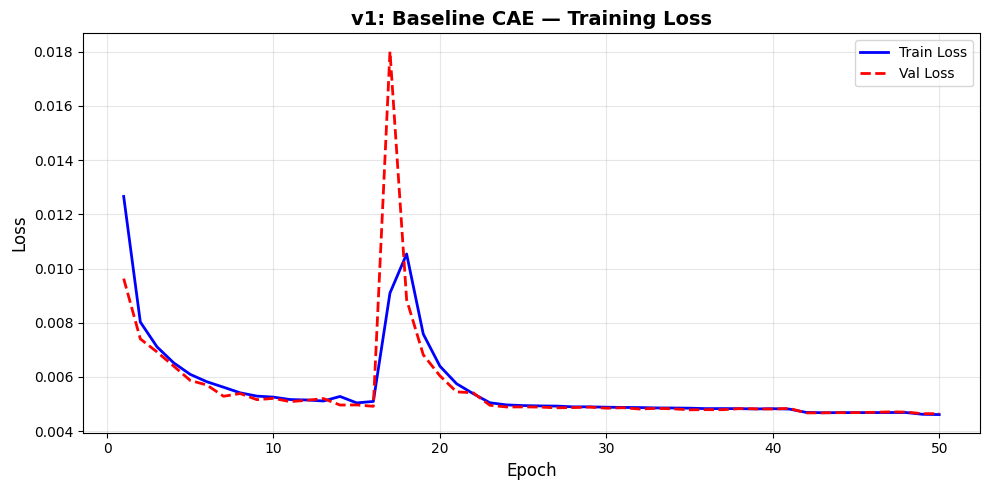

In [ ]:
# ─── Train v1: Baseline CAE ─────────────────────────────────────────
print('\n' + '█' * 70)
print(' TRAINING v1: Baseline Convolutional Autoencoder')
print('█' * 70)

model_v1 = get_model('v1')
history_v1 = train_model(
    model=model_v1,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    version='v1',
    save_dir=MODELS_DIR,
    **TRAIN_CONFIGS['v1'],
)
all_histories['v1'] = history_v1

plot_loss_curves(
    history_v1['train_total'], history_v1['val_total'],
    title='v1: Baseline CAE — Training Loss',
    save_path=os.path.join(PLOTS_DIR, 'loss_v1.png'),
)


██████████████████████████████████████████████████████████████████████
 TRAINING v2: BatchNorm Autoencoder
██████████████████████████████████████████████████████████████████████
[Model] V2 | AEv2 | latent=128 | params=14,273,345 | VAE=False

 Training V2 | Epochs: 50 | LR: 0.001
 Loss weights — α(MSE): 0.5 | β(SSIM): 0.5 | γ(KL): 0.0
 β-annealing: False (max=0.001)
 Device: cuda | Patience: 10



  Epoch   1/50 │ Train: 0.272227 │ Val: 0.274882 │ MSE: 0.038293 │ SSIM: 0.511471
[Checkpoint] Saved → /content/outputs/models/best_v2.pth (epoch=1, loss=0.274882)


  Epoch   2/50 │ Train: 0.272218 │ Val: 0.274814 │ MSE: 0.038199 │ SSIM: 0.511429
[Checkpoint] Saved → /content/outputs/models/best_v2.pth (epoch=2, loss=0.274814)


  Epoch   3/50 │ Train: 0.272220 │ Val: 0.274816 │ MSE: 0.038193 │ SSIM: 0.511440


  Epoch   4/50 │ Train: 0.272234 │ Val: 0.274803 │ MSE: 0.038159 │ SSIM: 0.511446
[Checkpoint] Saved → /content/outputs/models/best_v2.pth (epoch=4, loss=0.274803)


...

  Epoch  10/50 │ Train: 0.272173 │ Val: 0.274818 │ MSE: 0.038180 │ SSIM: 0.511456


  Epoch  11/50 │ Train: 0.272176 │ Val: 0.274829 │ MSE: 0.038244 │ SSIM: 0.511415


  Epoch  12/50 │ Train: 0.272192 │ Val: 0.274887 │ MSE: 0.038349 │ SSIM: 0.511425


  Epoch  13/50 │ Train: 0.272199 │ Val: 0.274828 │ MSE: 0.038242 │ SSIM: 0.511413


  Epoch  14/50 │ Train: 0.272215 │ Val: 0.274832 │ MSE: 0.038238 │ SSIM: 0.511425

  ⚡ Early stopping at epoch 14 (patience=10)

  ✓ Training complete in 5.6 min
  ✓ Best val loss: 0.274803 → /content/outputs/models/best_v2.pth

[Checkpoint] Saved → /content/outputs/models/final_v2.pth (epoch=14, loss=0.274832)
[Plot] Saved → /content/outputs/plots/loss_v2.png


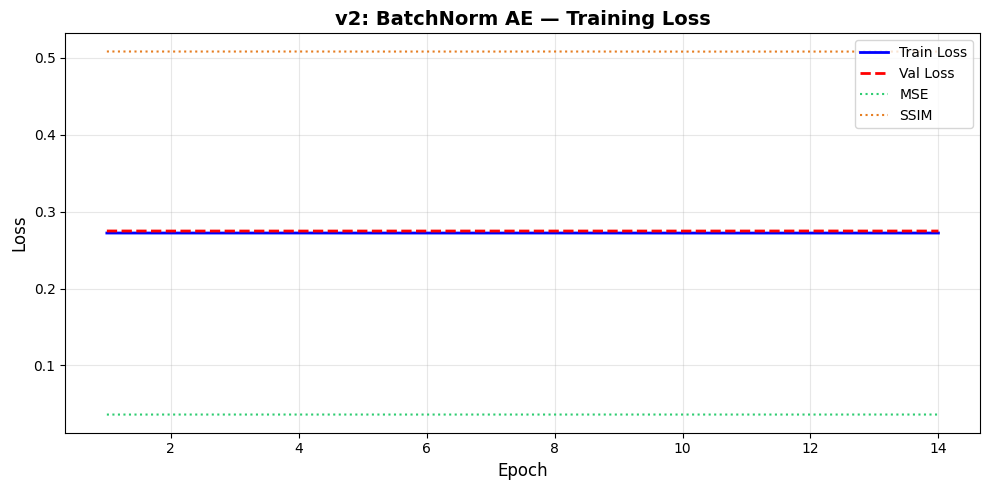

In [ ]:
# ─── Train v2: BatchNorm AE ─────────────────────────────────────────
print('\n' + '█' * 70)
print(' TRAINING v2: BatchNorm Autoencoder')
print('█' * 70)

model_v2 = get_model('v2')
history_v2 = train_model(
    model=model_v2,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    version='v2',
    save_dir=MODELS_DIR,
    **TRAIN_CONFIGS['v2'],
)
all_histories['v2'] = history_v2

plot_loss_curves(
    history_v2['train_total'], history_v2['val_total'],
    title='v2: BatchNorm AE — Training Loss',
    save_path=os.path.join(PLOTS_DIR, 'loss_v2.png'),
    components={'MSE': history_v2['train_mse'], 'SSIM': history_v2['train_ssim']},
)


██████████████████████████████████████████████████████████████████████
 TRAINING v3: Variational Autoencoder
██████████████████████████████████████████████████████████████████████
[Model] V3 | AEv3 | latent=256 | params=18,446,401 | VAE=False

 Training V3 | Epochs: 50 | LR: 0.001
 Loss weights — α(MSE): 0.5 | β(SSIM): 0.5 | γ(KL): 0.001
 β-annealing: False (max=0.001)
 Device: cuda | Patience: 10



  Epoch   1/50 │ Train: 0.266453 │ Val: 0.248539 │ MSE: 0.020791 │ SSIM: 0.476287
[Checkpoint] Saved → /content/outputs/models/best_v3.pth (epoch=1, loss=0.248539)


  Epoch   2/50 │ Train: 0.239719 │ Val: 0.232374 │ MSE: 0.010498 │ SSIM: 0.454250
[Checkpoint] Saved → /content/outputs/models/best_v3.pth (epoch=2, loss=0.232374)


  Epoch   3/50 │ Train: 0.234154 │ Val: 0.229101 │ MSE: 0.010657 │ SSIM: 0.447546
[Checkpoint] Saved → /content/outputs/models/best_v3.pth (epoch=3, loss=0.229101)


  Epoch   4/50 │ Train: 0.231255 │ Val: 0.234117 │ MSE: 0.012858 │ SSIM: 0.455377


...

  Epoch  37/50 │ Train: 0.182407 │ Val: 0.190987 │ MSE: 0.005110 │ SSIM: 0.376864


  Epoch  38/50 │ Train: 0.178215 │ Val: 0.190461 │ MSE: 0.004970 │ SSIM: 0.375951


  Epoch  39/50 │ Train: 0.176385 │ Val: 0.191112 │ MSE: 0.004940 │ SSIM: 0.377283


  Epoch  40/50 │ Train: 0.175203 │ Val: 0.191536 │ MSE: 0.005056 │ SSIM: 0.378015


  Epoch  41/50 │ Train: 0.174137 │ Val: 0.194245 │ MSE: 0.005328 │ SSIM: 0.383162

  ⚡ Early stopping at epoch 41 (patience=10)

  ✓ Training complete in 22.8 min
  ✓ Best val loss: 0.189463 → /content/outputs/models/best_v3.pth

[Checkpoint] Saved → /content/outputs/models/final_v3.pth (epoch=41, loss=0.194245)
[Plot] Saved → /content/outputs/plots/loss_v3.png


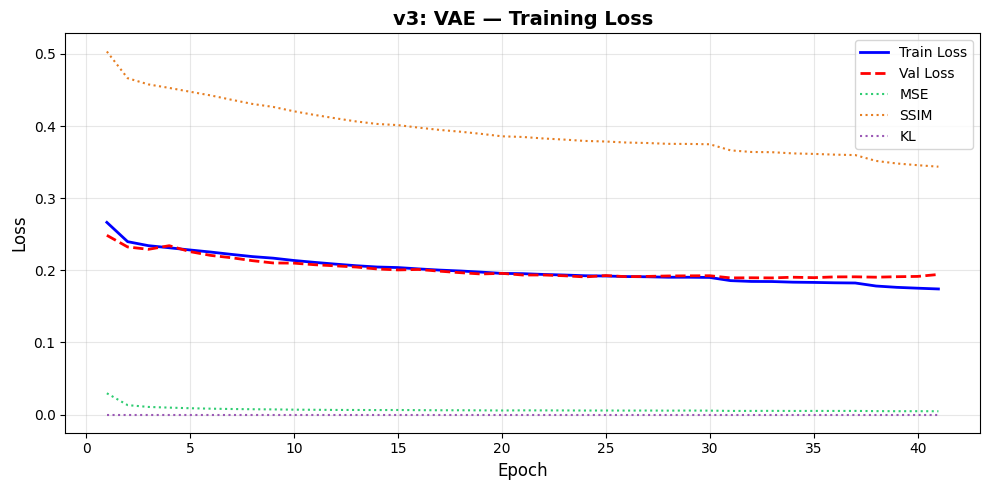

In [ ]:
# ─── Train v3: Variational Autoencoder ──────────────────────────────
print('\n' + '█' * 70)
print(' TRAINING v3: Variational Autoencoder')
print('█' * 70)

model_v3 = get_model('v3')
history_v3 = train_model(
    model=model_v3,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    version='v3',
    save_dir=MODELS_DIR,
    **TRAIN_CONFIGS['v3'],
)
all_histories['v3'] = history_v3

plot_loss_curves(
    history_v3['train_total'], history_v3['val_total'],
    title='v3: VAE — Training Loss',
    save_path=os.path.join(PLOTS_DIR, 'loss_v3.png'),
    components={
        'MSE': history_v3['train_mse'],
        'SSIM': history_v3['train_ssim'],
        'KL': history_v3['train_kl'],
    },
)

In [ ]:
import src.losses as losses_module
import torch

def kl_divergence_clamped(mu, logvar):
    logvar = torch.clamp(logvar, min=-10, max=10)   # bounds exp() to a sane range
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

losses_module.kl_divergence = kl_divergence_clamped
print("Patched kl_divergence with logvar clamp")

Patched kl_divergence with logvar clamp


In [ ]:
!rm -f /content/outputs/models/best_v4.pth

In [ ]:
!mkdir -p /content/drive/MyDrive/nssc2026/ASTRA_run_outputs
!cp -r /content/outputs /content/drive/MyDrive/nssc2026/ASTRA_run_outputs/
!ls /content/drive/MyDrive/nssc2026/ASTRA_run_outputs/outputs

models	plots


In [ ]:
# Re-create v4 fresh — don't reuse the old model/optimizer objects
model_v4 = get_model('v4').to(device)  # use whatever the actual constructor call is in their code
optimizer_v4 = torch.optim.Adam(model_v4.parameters(), lr=1e-3)  # match their actual v4 optimizer setup

# Confirm the patch is still active in this session
import src.losses as losses_module
print(losses_module.kl_divergence)  # should show your patched function, not the original

[Model] V4 | AEv4 | latent=256 | params=24,869,185 | VAE=True
<function kl_divergence_clamped at 0x7c2909741120>


In [ ]:
batch = next(iter(train_loader))
print(type(batch), len(batch))
for item in batch:
    print(type(item), item.shape if hasattr(item, 'shape') else item[:3])

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


<class 'list'> 3
<class 'torch.Tensor'> torch.Size([32, 1, 227, 227])
<class 'tuple'> ('sample_10372.jpg', 'sample_09016.jpg', 'sample_05447.jpg')
<class 'tuple'> ('SRC_150', 'SRC_146', 'SRC_089')


In [ ]:
model_v4.train()
batch_iter = iter(train_loader)

# Define criterion for v4 model
criterion = CombinedLoss(
    alpha=TRAIN_CONFIGS['v4']['alpha'],
    beta=TRAIN_CONFIGS['v4']['beta'],
    gamma=TRAIN_CONFIGS['v4']['gamma']
).to(device)

# Enable anomaly detection to find the source of NaNs
torch.autograd.set_detect_anomaly(True)

for i in range(3):
    # Robustly unpack items from the batch_iter
    images, filenames, *_ = next(batch_iter)
    images = images.to(device)

    recon, mu, logvar = model_v4(images)

    print(f"--- batch {i} ---")
    print("recon has nan:", torch.isnan(recon).any().item(), "| has inf:", torch.isinf(recon).any().item())
    print("mu has nan:", torch.isnan(mu).any().item(), "| mu range:", mu.min().item(), mu.max().item())
    print("logvar has nan:", torch.isnan(logvar).any().item(), "| logvar range:", logvar.min().item(), logvar.max().item())

    loss, loss_dict = criterion(recon, images, mu, logvar)
    print("loss_dict:", loss_dict)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


--- batch 0 ---
recon has nan: False | has inf: False
mu has nan: False | mu range: -20.17044448852539 21.405563354492188
logvar has nan: False | logvar range: -275.4146423339844 102.07203674316406
loss_dict: {'mse': 0.03722904995083809, 'ssim': 0.6132003664970398, 'kl': 11.922826766967773, 'total': 0.3371375501155853}
--- batch 1 ---
recon has nan: True | has inf: False
mu has nan: False | mu range: -19.045141220092773 19.34004020690918
logvar has nan: False | logvar range: -239.54925537109375 176.11595153808594
loss_dict: {'mse': nan, 'ssim': nan, 'kl': 20.627426147460938, 'total': nan}
--- batch 2 ---
recon has nan: False | has inf: False
mu has nan: False | mu range: -28.73858642578125 19.697885513305664
logvar has nan: False | logvar range: -240.88174438476562 64.44001007080078
loss_dict: {'mse': 0.041427936404943466, 'ssim': 0.529070258140564, 'kl': 15.385478973388672, 'total': 0.30063456296920776}


In [ ]:
import src.losses as losses_module
import torch.nn.functional as F

class SSIMLossSafe(losses_module.SSIMLoss):
    def forward(self, prediction, target):
        pad = self.window_size // 2
        mu_x = F.conv2d(prediction, self.window, padding=pad, groups=self.channels)
        mu_y = F.conv2d(target, self.window, padding=pad, groups=self.channels)
        mu_x_sq, mu_y_sq, mu_xy = mu_x**2, mu_y**2, mu_x*mu_y
        sigma_x_sq = F.conv2d(prediction**2, self.window, padding=pad, groups=self.channels) - mu_x_sq
        sigma_y_sq = F.conv2d(target**2, self.window, padding=pad, groups=self.channels) - mu_y_sq
        sigma_xy = F.conv2d(prediction*target, self.window, padding=pad, groups=self.channels) - mu_xy

        numerator = (2*mu_xy + self.C1) * (2*sigma_xy + self.C2)
        denominator = (mu_x_sq + mu_y_sq + self.C1) * (sigma_x_sq + sigma_y_sq + self.C2)
        # Extra epsilon specifically to keep the GRADIENT of this division stable,
        # not just the forward value — C1/C2 alone weren't enough.
        ssim_map = numerator / (denominator + 1e-8)
        return 1.0 - ssim_map.mean()

losses_module.SSIMLoss = SSIMLossSafe
print("Patched SSIMLoss with gradient-safe denominator")

Patched SSIMLoss with gradient-safe denominator


In [ ]:
model_v4 = get_model('v4').to(device)
optimizer_v4 = torch.optim.Adam(model_v4.parameters(), lr=1e-3)
criterion = CombinedLoss(alpha=..., beta=..., gamma=...)  # same args as before, whatever their v4 config used

[Model] V4 | AEv4 | latent=256 | params=24,869,185 | VAE=True


In [ ]:
print(type(criterion.ssim))  # should say SSIMLossSafe, not SSIMLoss

<class '__main__.SSIMLossSafe'>


In [ ]:
import inspect
print(inspect.signature(train_model))

(model: torch.nn.modules.module.Module, train_loader: torch.utils.data.dataloader.DataLoader, val_loader: torch.utils.data.dataloader.DataLoader, device: torch.device, version: str = 'v1', epochs: int = 50, lr: float = 0.001, weight_decay: float = 1e-05, alpha: float = 1.0, beta: float = 1.0, gamma: float = 0.0, patience: int = 10, grad_clip: float = 1.0, beta_annealing: bool = False, beta_max: float = 0.001, save_dir: str = 'outputs/models') -> dict


In [ ]:
print(losses_module.SSIMLoss)  # should print SSIMLossSafe, not SSIMLoss

<class '__main__.SSIMLossSafe'>


In [ ]:
print(inspect.getsourcefile(train_model))

/content/ASTRA/src/train.py


In [ ]:
with open('/content/ASTRA/src/losses.py', 'r') as f:
    content = f.read()

# Fix 1: SSIM division-by-near-zero gradient explosion
content = content.replace(
    "ssim_map = numerator / denominator",
    "ssim_map = numerator / (denominator + 1e-8)"
)

# Fix 2: KL logvar explosion (in case this instance of the file still lacks it)
content = content.replace(
    "return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())",
    "logvar = torch.clamp(logvar, min=-10, max=10)\n    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())"
)

with open('/content/ASTRA/src/losses.py', 'w') as f:
    f.write(content)

print("Patched losses.py on disk")

Patched losses.py on disk


In [ ]:
import importlib
import src.losses
import src.train

importlib.reload(src.losses)
importlib.reload(src.train)

from src.losses import CombinedLoss, kl_divergence
from src.train import train_model

print("Modules reloaded from patched files")

Modules reloaded from patched files


In [ ]:
!grep -A1 "ssim_map = numerator" /content/ASTRA/src/losses.py
!grep -B1 "return -0.5" /content/ASTRA/src/losses.py

        ssim_map = numerator / (denominator + 1e-8)

    logvar = torch.clamp(logvar, min=-10, max=10)
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


In [ ]:
with open('/content/ASTRA/src/losses.py', 'r') as f:
    content = f.read()

# Revert the too-small epsilon and replace with a stronger fix
content = content.replace(
    "ssim_map = numerator / (denominator + 1e-8)",
    "ssim_map = numerator / (denominator + 1e-4)\n        ssim_map = torch.clamp(ssim_map, min=-1.0, max=1.0)"
)

with open('/content/ASTRA/src/losses.py', 'w') as f:
    f.write(content)

print("Re-patched with larger epsilon + SSIM clamp")

!grep -A2 "ssim_map = numerator" /content/ASTRA/src/losses.py

Re-patched with larger epsilon + SSIM clamp
        ssim_map = numerator / (denominator + 1e-4)
        ssim_map = torch.clamp(ssim_map, min=-1.0, max=1.0)



In [ ]:
with open('/content/ASTRA/src/losses.py', 'r') as f:
    content = f.read()

old_block = """        numerator = (2 * mu_xy + self.C1) * (2 * sigma_xy + self.C2)
        denominator = (mu_x_sq + mu_y_sq + self.C1) * (sigma_x_sq + sigma_y_sq + self.C2)
        ssim_map = numerator / (denominator + 1e-4)
        ssim_map = torch.clamp(ssim_map, min=-1.0, max=1.0)"""

new_block = """        # Variance can't legitimately be negative — clamp away floating-point roundoff
        # on near-constant patches (e.g. flat sky, black image borders).
        sigma_x_sq = torch.clamp(sigma_x_sq, min=0.0)
        sigma_y_sq = torch.clamp(sigma_y_sq, min=0.0)

        numerator = (2 * mu_xy + self.C1) * (2 * sigma_xy + self.C2)
        denominator = (mu_x_sq + mu_y_sq + self.C1) * (sigma_x_sq + sigma_y_sq + self.C2)
        # Hard floor, not just an additive epsilon — denominator must be strictly positive
        # before dividing, or the gradient can still explode near a zero-crossing.
        denominator = torch.clamp(denominator, min=1e-4)
        ssim_map = numerator / denominator
        ssim_map = torch.clamp(ssim_map, min=-1.0, max=1.0)"""

if old_block not in content:
    print("WARNING: old_block not found verbatim — check for whitespace mismatch, don't blind-write")
else:
    content = content.replace(old_block, new_block)
    with open('/content/ASTRA/src/losses.py', 'w') as f:
        f.write(content)
    print("Patched: variance clamp + hard denominator floor")

!grep -B2 -A6 "Variance can't" /content/ASTRA/src/losses.py

Patched: variance clamp + hard denominator floor

        # SSIM formula
        # Variance can't legitimately be negative — clamp away floating-point roundoff
        # on near-constant patches (e.g. flat sky, black image borders).
        sigma_x_sq = torch.clamp(sigma_x_sq, min=0.0)
        sigma_y_sq = torch.clamp(sigma_y_sq, min=0.0)

        numerator = (2 * mu_xy + self.C1) * (2 * sigma_xy + self.C2)
        denominator = (mu_x_sq + mu_y_sq + self.C1) * (sigma_x_sq + sigma_y_sq + self.C2)


In [ ]:
importlib.reload(src.losses)
importlib.reload(src.train)
from src.losses import CombinedLoss, kl_divergence
from src.train import train_model

model_v4 = get_model('v4').to(device)
history_v4 = train_model(
    model=model_v4, train_loader=train_loader, val_loader=val_loader,
    device=device, version='v4', epochs=50, gamma=0.001, grad_clip=1.0,
)

[Model] V4 | AEv4 | latent=256 | params=24,869,185 | VAE=True

 Training V4 | Epochs: 50 | LR: 0.001
 Loss weights — α(MSE): 1.0 | β(SSIM): 1.0 | γ(KL): 0.001
 β-annealing: False (max=0.001)
 Device: cuda | Patience: 10



  Train:  24%|██▍       | 70/293 [00:11<00:33,  6.60it/s]/usr/local/lib/python3.13/dist-packages/torch/autograd/graph.py:869: UserWarning: Error detected in DivBackward0. Traceback of forward call that caused the error:
  File "<frozen runpy>", line 203, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.13/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.13/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.13/dist-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.13/asyncio/base_events.py", line 684, in run_forever
    self._run_once()
  File "/usr/lib/python3.13/asyncio/base_events.py", line 2061, in

RuntimeError: Function 'DivBackward0' returned nan values in its 0th output.

In [ ]:
model_v4 = get_model('v4').to(device)
history_v4 = train_model(
    model=model_v4,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    version='v4',
    epochs=50,
    alpha=1.0,
    beta=0.0,     # SSIM disabled — known bug, revisit later
    gamma=0.001,
    grad_clip=1.0,
)

[Model] V4 | AEv4 | latent=256 | params=24,869,185 | VAE=True

 Training V4 | Epochs: 50 | LR: 0.001
 Loss weights — α(MSE): 1.0 | β(SSIM): 0.0 | γ(KL): 0.001
 β-annealing: False (max=0.001)
 Device: cuda | Patience: 10



  Epoch   1/50 │ Train: 0.028036 │ Val: 0.044396 │ MSE: 0.039403 │ SSIM: 0.516199
[Checkpoint] Saved → outputs/models/best_v4.pth (epoch=1, loss=0.044396)


  Epoch   2/50 │ Train: 0.018900 │ Val: 0.042184 │ MSE: 0.038176 │ SSIM: 0.517112
[Checkpoint] Saved → outputs/models/best_v4.pth (epoch=2, loss=0.042184)


  Epoch   3/50 │ Train: 0.014714 │ Val: 0.045222 │ MSE: 0.039007 │ SSIM: 0.515596


  Epoch   4/50 │ Train: 0.012884 │ Val: 0.040855 │ MSE: 0.037940 │ SSIM: 0.516475
[Checkpoint] Saved → outputs/models/best_v4.pth (epoch=4, loss=0.040855)


...

  Epoch  35/50 │ Train: 0.006283 │ Val: 0.038839 │ MSE: 0.038208 │ SSIM: 0.512575


  Epoch  36/50 │ Train: 0.006220 │ Val: 0.038871 │ MSE: 0.038262 │ SSIM: 0.512230


  Epoch  37/50 │ Train: 0.006244 │ Val: 0.038862 │ MSE: 0.038225 │ SSIM: 0.512562


  Epoch  38/50 │ Train: 0.006218 │ Val: 0.038663 │ MSE: 0.038030 │ SSIM: 0.512899


  Epoch  39/50 │ Train: 0.006249 │ Val: 0.038889 │ MSE: 0.038252 │ SSIM: 0.512267

  ⚡ Early stopping at epoch 39 (patience=10)

  ✓ Training complete in 31.4 min
  ✓ Best val loss: 0.038652 → outputs/models/best_v4.pth

[Checkpoint] Saved → outputs/models/final_v4.pth (epoch=39, loss=0.038889)



██████████████████████████████████████████████████████████████████████
 TRAINING v5: β-VAE + Skip + LeakyReLU (β-annealing)
██████████████████████████████████████████████████████████████████████
[Model] V5 | AEv5 | latent=256 | params=25,557,825 | VAE=True

 Training V5 | Epochs: 50 | LR: 0.001
 Loss weights — α(MSE): 0.5 | β(SSIM): 0.5 | γ(KL): 0.0
 β-annealing: True (max=0.005)
 Device: cuda | Patience: 10



  Epoch   1/50 │ Train: 0.038995 │ Val: 0.033546 │ MSE: 0.001111 │ SSIM: 0.065541 | γ=0.000200
[Checkpoint] Saved → /content/outputs/models/best_v5.pth (epoch=1, loss=0.033546)


  Epoch   2/50 │ Train: 0.026309 │ Val: 0.028489 │ MSE: 0.001384 │ SSIM: 0.054299 | γ=0.000400
[Checkpoint] Saved → /content/outputs/models/best_v5.pth (epoch=2, loss=0.028489)


  Epoch   3/50 │ Train: 0.025551 │ Val: 0.029594 │ MSE: 0.000947 │ SSIM: 0.057814 | γ=0.000600


  Epoch   4/50 │ Train: 0.025016 │ Val: 0.033703 │ MSE: 0.001082 │ SSIM: 0.065921 | γ=0.000800


...

  Epoch  46/50 │ Train: 0.020814 │ Val: 0.026083 │ MSE: 0.001073 │ SSIM: 0.051094 | γ=0.005000


  Epoch  47/50 │ Train: 0.020812 │ Val: 0.024431 │ MSE: 0.000388 │ SSIM: 0.048474 | γ=0.005000


  Epoch  48/50 │ Train: 0.020636 │ Val: 0.024142 │ MSE: 0.000409 │ SSIM: 0.047875 | γ=0.005000


  Epoch  49/50 │ Train: 0.020722 │ Val: 0.023944 │ MSE: 0.000387 │ SSIM: 0.047501 | γ=0.005000
[Checkpoint] Saved → /content/outputs/models/best_v5.pth (epoch=49, loss=0.023944)


  Epoch  50/50 │ Train: 0.020682 │ Val: 0.023862 │ MSE: 0.000285 │ SSIM: 0.047439 | γ=0.005000
[Checkpoint] Saved → /content/outputs/models/best_v5.pth (epoch=50, loss=0.023862)

  ✓ Training complete in 45.5 min
  ✓ Best val loss: 0.023862 → /content/outputs/models/best_v5.pth

[Checkpoint] Saved → /content/outputs/models/final_v5.pth (epoch=50, loss=0.023862)
[Plot] Saved → /content/outputs/plots/loss_v5.png


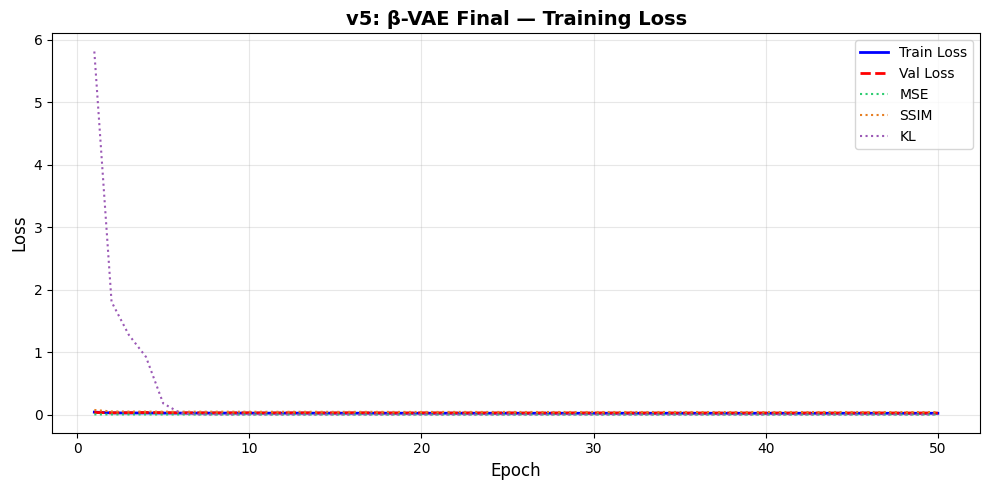

In [ ]:
# ─── Train v5: β-VAE + Skip + LeakyReLU ─────────────────────────────
print('\n' + '█' * 70)
print(' TRAINING v5: β-VAE + Skip + LeakyReLU (β-annealing)')
print('█' * 70)

model_v5 = get_model('v5')
history_v5 = train_model(
    model=model_v5,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    version='v5',
    save_dir=MODELS_DIR,
    **TRAIN_CONFIGS['v5'],
)
all_histories['v5'] = history_v5

plot_loss_curves(
    history_v5['train_total'], history_v5['val_total'],
    title='v5: β-VAE Final — Training Loss',
    save_path=os.path.join(PLOTS_DIR, 'loss_v5.png'),
    components={
        'MSE': history_v5['train_mse'],
        'SSIM': history_v5['train_ssim'],
        'KL': history_v5['train_kl'],
    },
)

## 1.4 Reconstruction Quality Comparison

[Plot] Saved → /content/outputs/plots/recon_v1.png


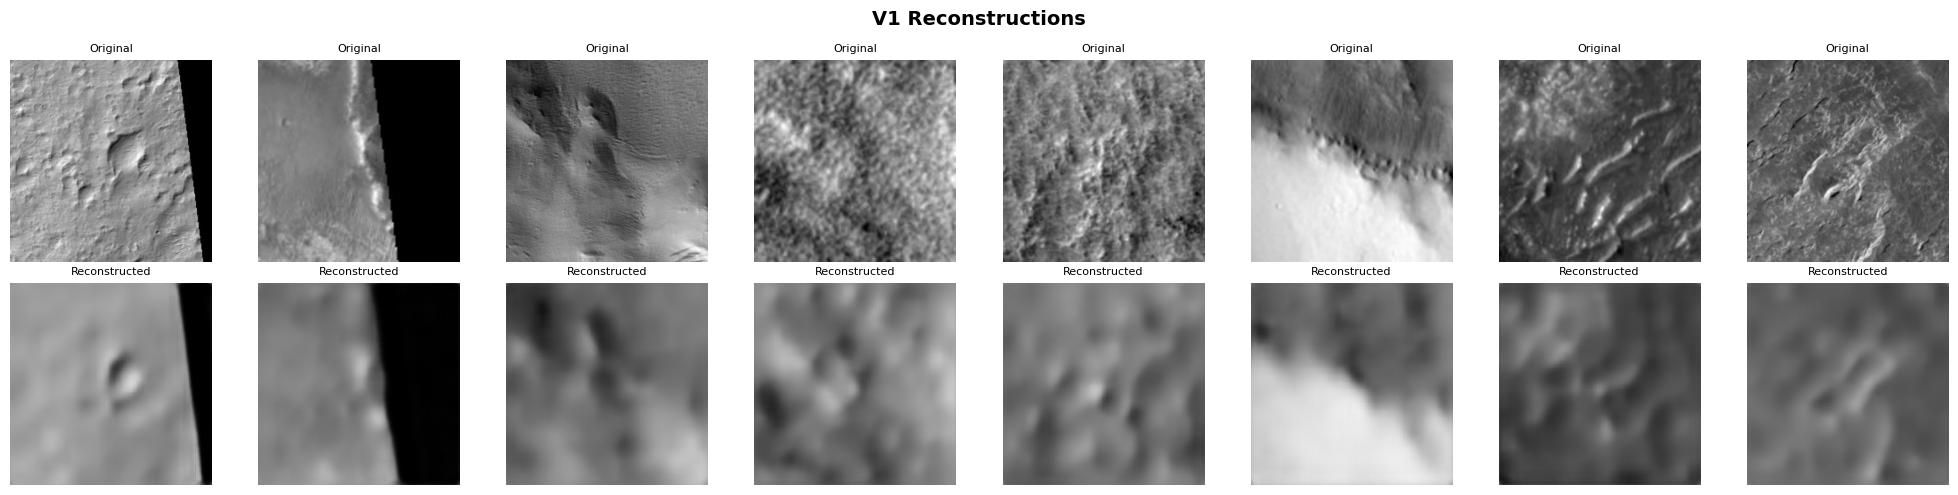

[Plot] Saved → /content/outputs/plots/recon_v2.png


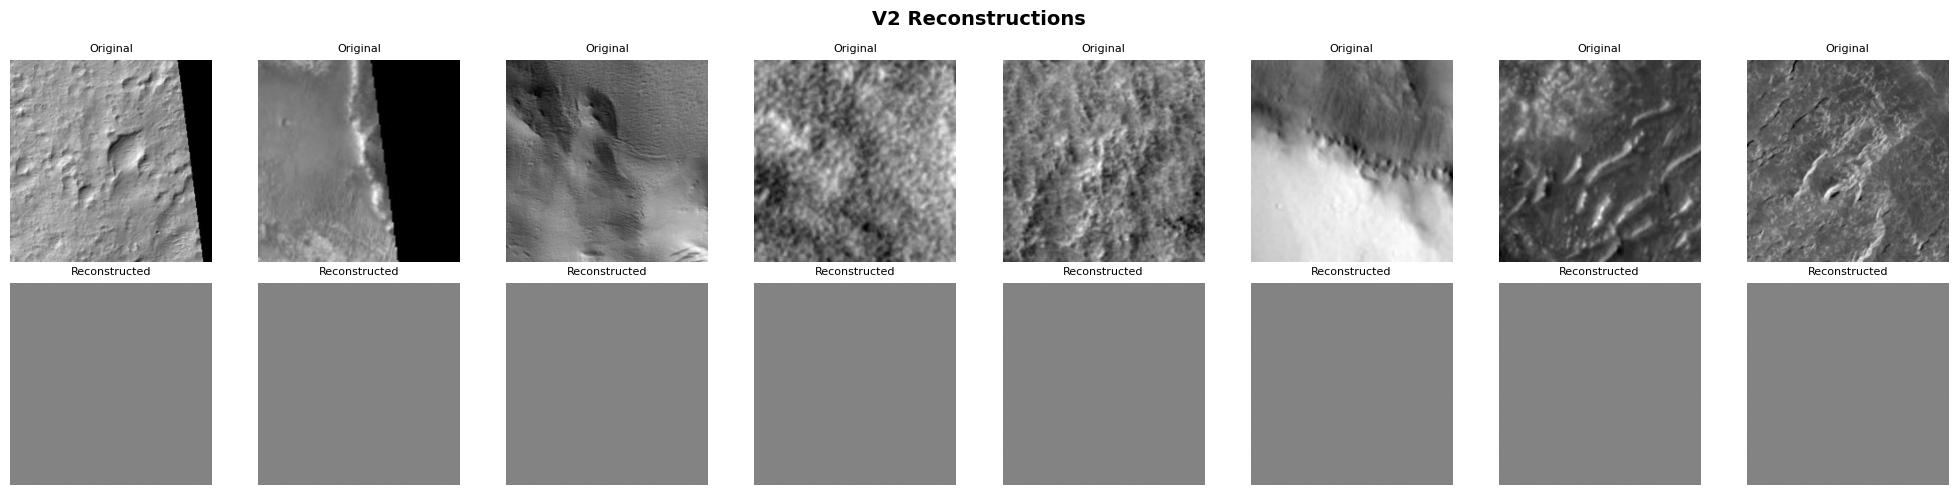

[Plot] Saved → /content/outputs/plots/recon_v3.png


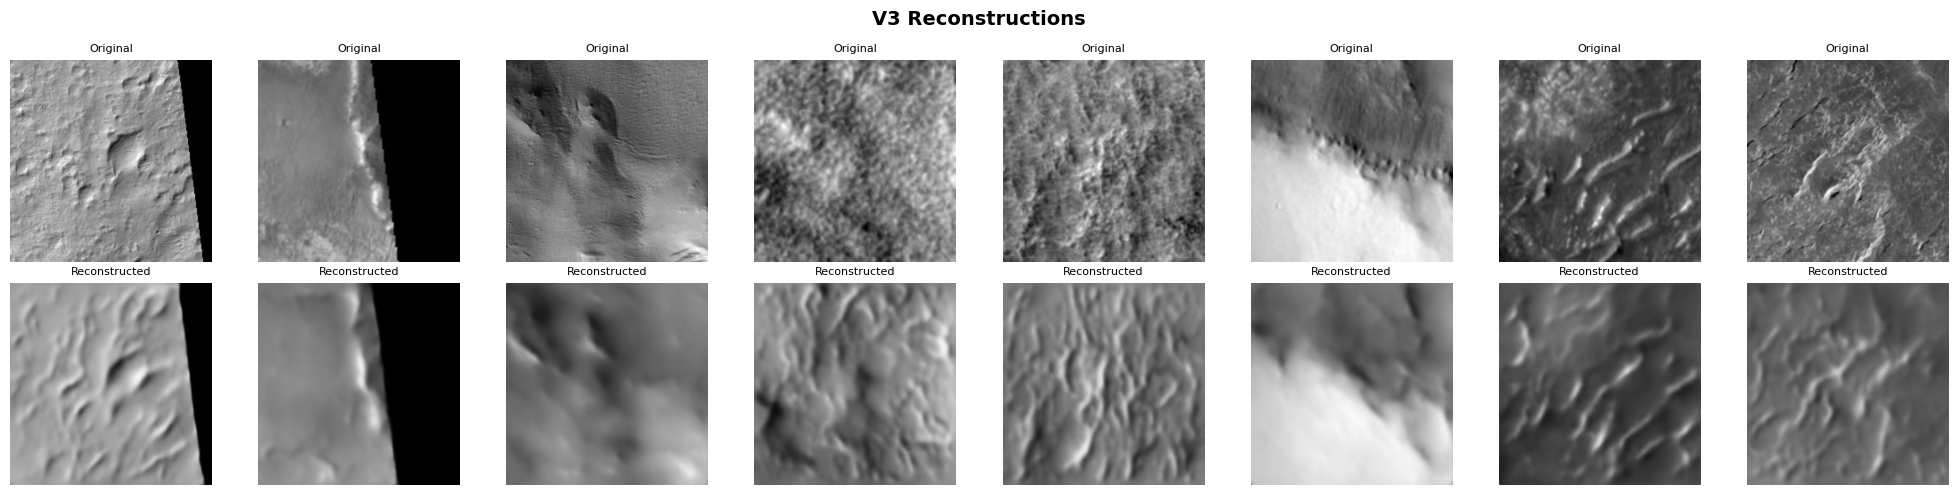

[Plot] Saved → /content/outputs/plots/recon_v4.png


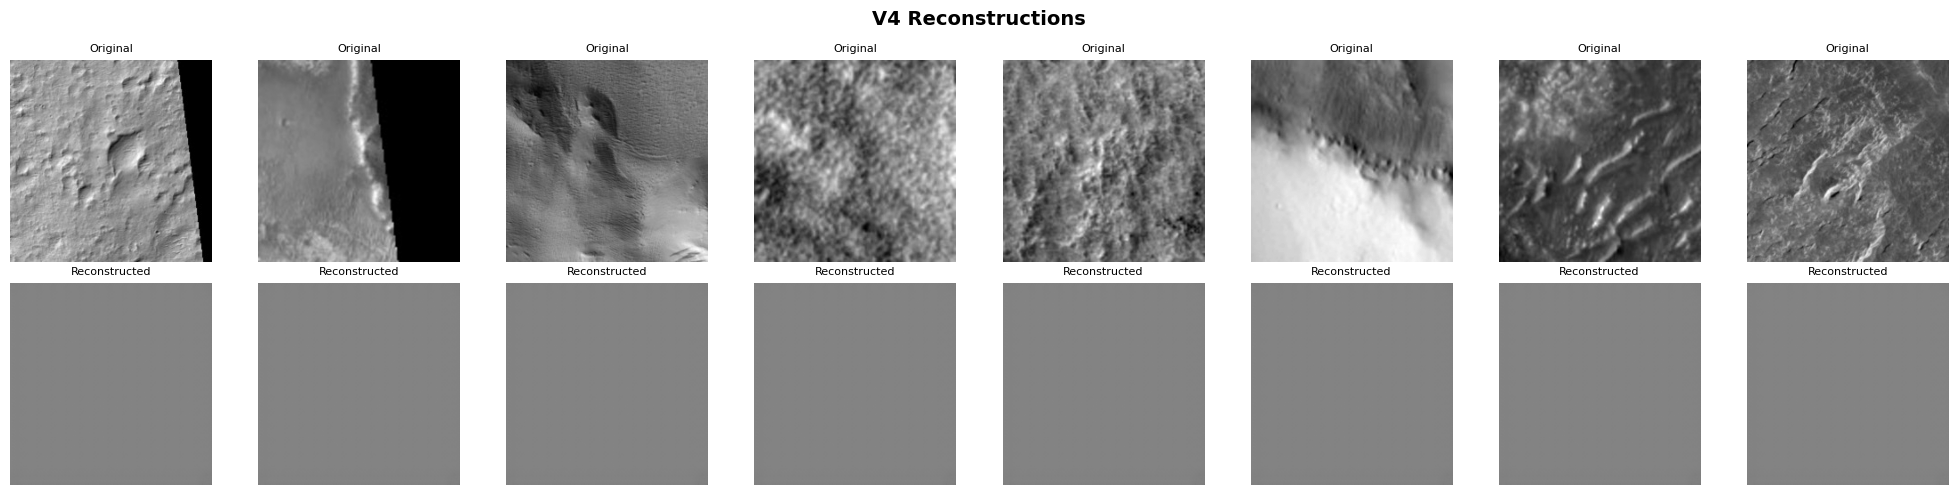

[Plot] Saved → /content/outputs/plots/recon_v5.png


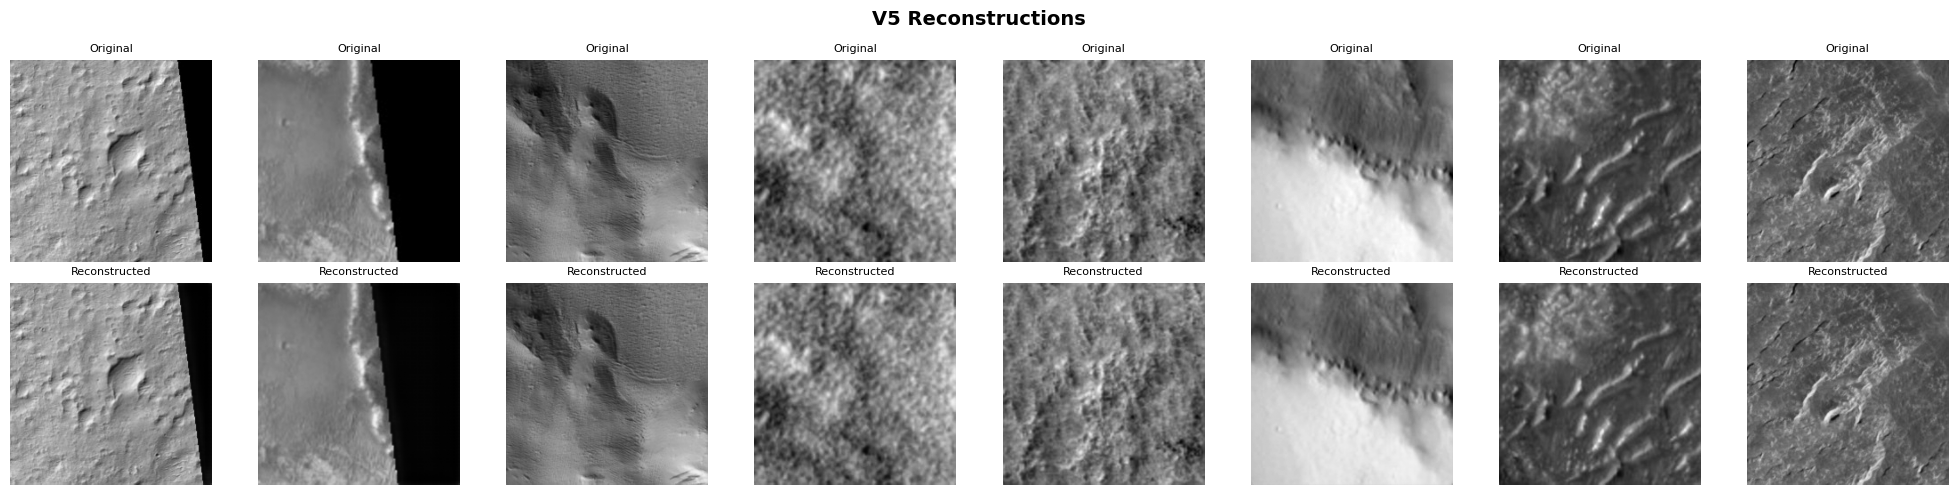

In [ ]:
# Visualize reconstructions from all 5 versions on the same batch
sample_images = next(iter(val_loader))[0][:8].to(device)

models = {
    'v1': model_v1, 'v2': model_v2, 'v3': model_v3,
    'v4': model_v4, 'v5': model_v5,
}

for version, model in models.items():
    model.eval()
    with torch.no_grad():
        output = model(sample_images)
        recon = output[0] if isinstance(output, tuple) else output

    plot_reconstructions(
        sample_images, recon, n=8,
        title=f'{version.upper()} Reconstructions',
        save_path=os.path.join(PLOTS_DIR, f'recon_{version}.png'),
    )

In [ ]:
with open('/content/ASTRA/src/latent_utils.py', 'r') as f:
    content = f.read()

content = content.replace(
    "images, fnames = batch",
    "images, fnames, _source_ids = batch"
)

with open('/content/ASTRA/src/latent_utils.py', 'w') as f:
    f.write(content)

print("Patched latent_utils.py")
!grep -n "images, fnames" /content/ASTRA/src/latent_utils.py

Patched latent_utils.py
42:            images, fnames, _source_ids = batch


## 1.4 Reconstruction Quality Comparison


--- Extracting latents for V1 ---


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Latent] Extracted 10422 vectors of dim 128
[Latent] Saved → /content/outputs/latent_vectors/latents_v1.npy
[t-SNE] Computing with perplexity=30...


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[Plot] Saved → /content/outputs/plots/tsne_v1.png


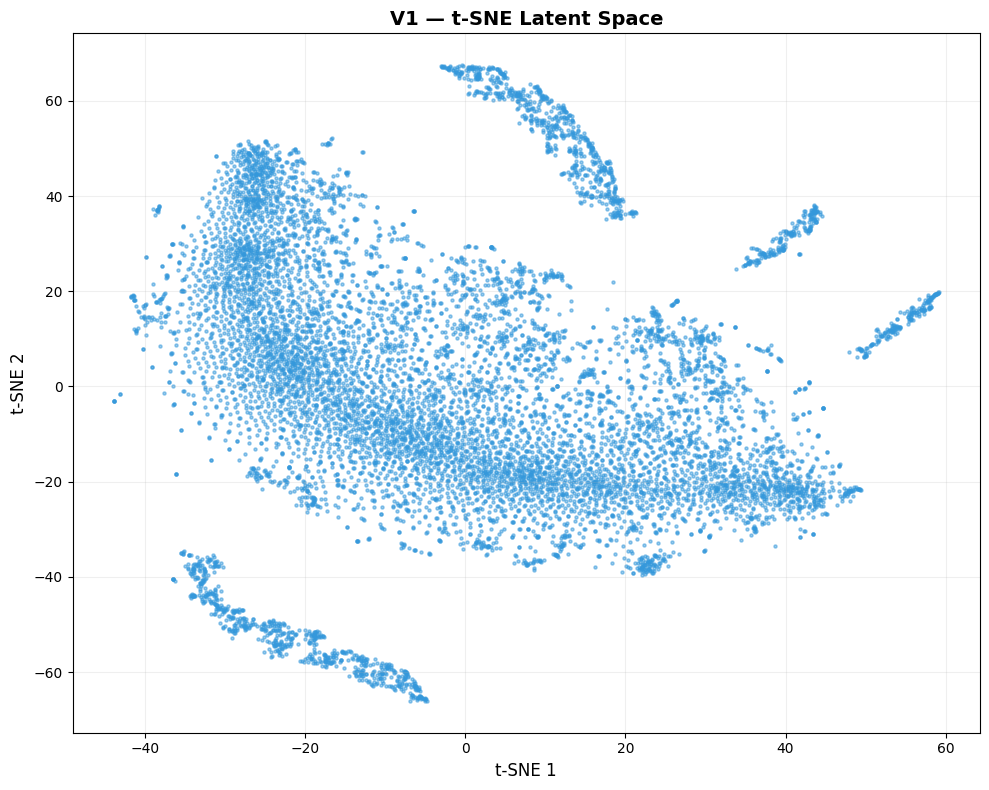

[UMAP] Computing with n_neighbors=15, min_dist=0.1...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Plot] Saved → /content/outputs/plots/umap_v1.png


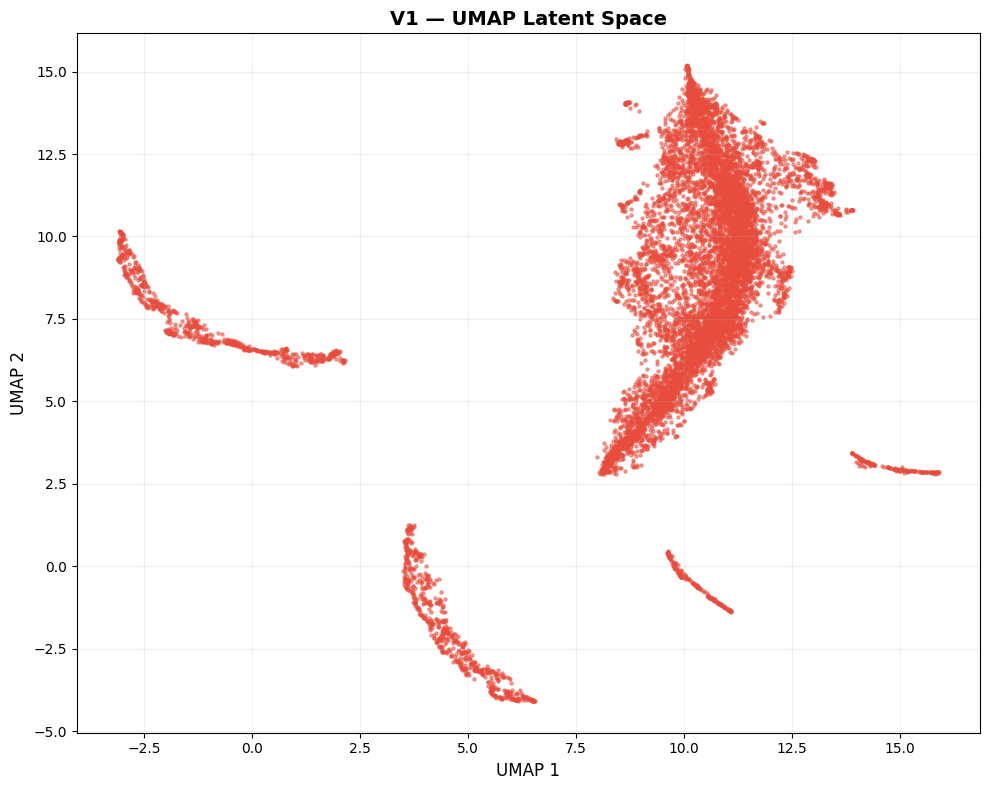


--- Extracting latents for V3 ---


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Latent] Extracted 10422 vectors of dim 256
[Latent] Saved → /content/outputs/latent_vectors/latents_v3.npy
[t-SNE] Computing with perplexity=30...


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[Plot] Saved → /content/outputs/plots/tsne_v3.png


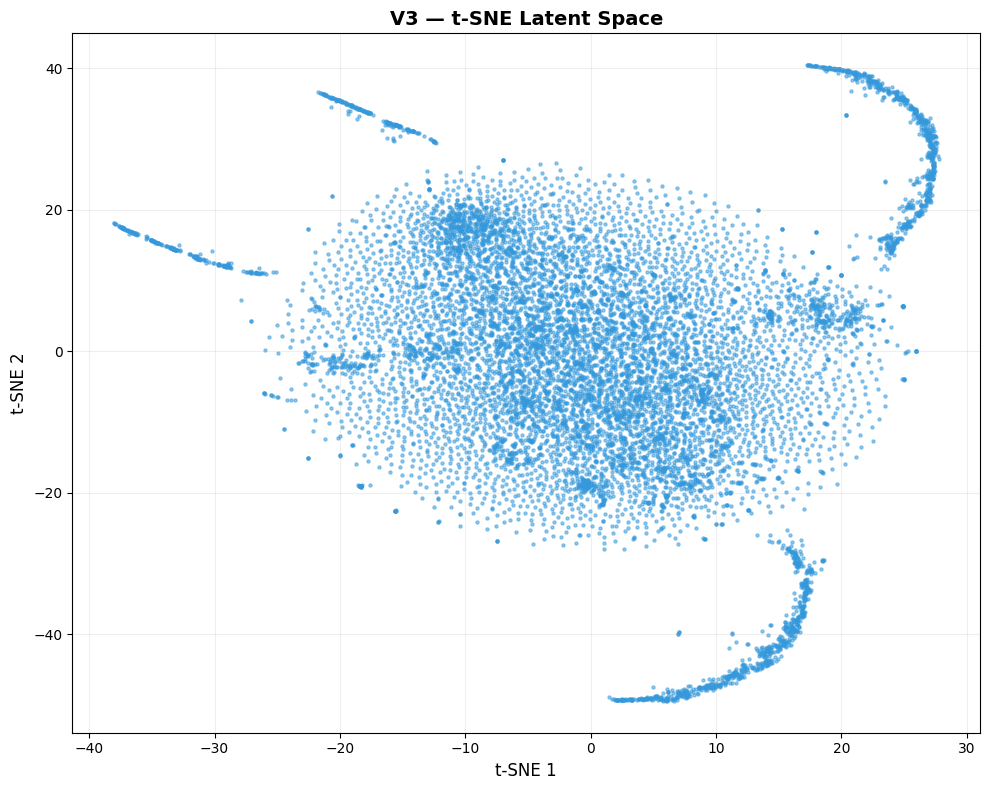

[UMAP] Computing with n_neighbors=15, min_dist=0.1...


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[Plot] Saved → /content/outputs/plots/umap_v3.png


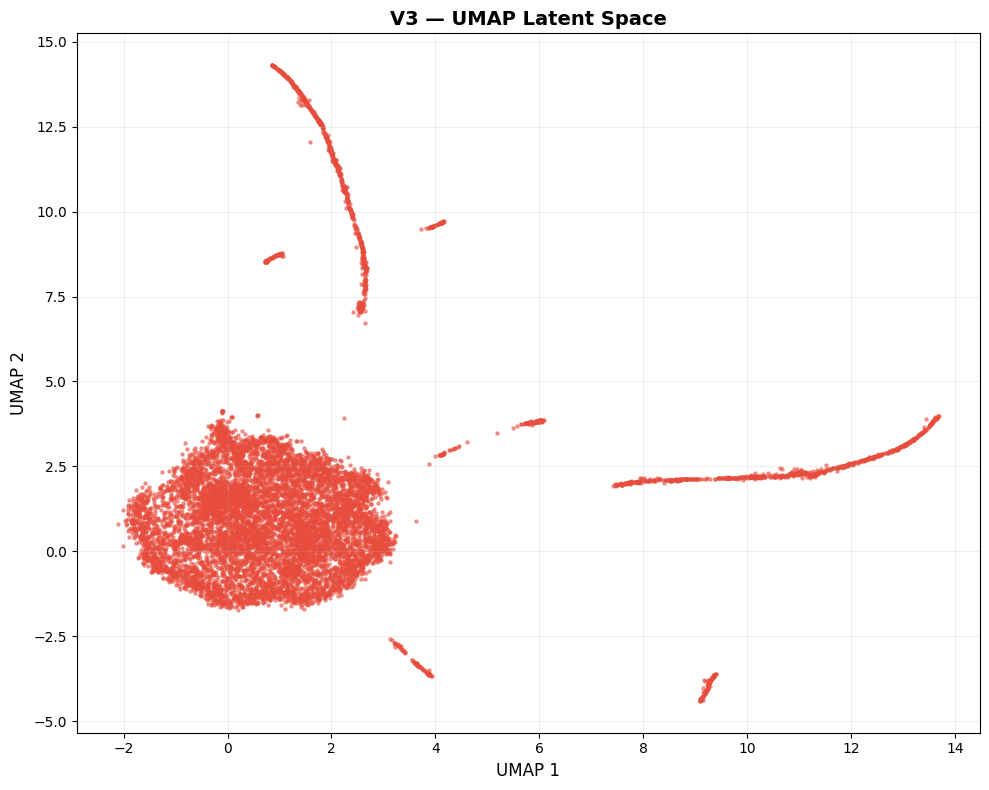


--- Extracting latents for V5 ---


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


[Latent] Extracted 10422 vectors of dim 256
[Latent] Saved → /content/outputs/latent_vectors/latents_v5.npy
[t-SNE] Computing with perplexity=30...


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
import importlib
import src.latent_utils
importlib.reload(src.latent_utils)
from src.latent_utils import extract_latents, save_latents, plot_tsne, plot_umap

for version, model in [('v1', model_v1), ('v3', model_v3), ('v5', model_v5)]:
    print(f'\n--- Extracting latents for {version.upper()} ---')
    model.to(device)
    latents, filenames = extract_latents(model, full_loader, device)
    save_latents(latents, filenames, save_dir=LATENT_DIR, version=version)

    plot_tsne(latents, perplexity=30, title=f'{version.upper()} — t-SNE Latent Space',
              save_path=os.path.join(PLOTS_DIR, f'tsne_{version}.png'))
    plot_umap(latents, n_neighbors=15, min_dist=0.1, title=f'{version.upper()} — UMAP Latent Space',
              save_path=os.path.join(PLOTS_DIR, f'umap_{version}.png'))

In [ ]:
import os
print(os.path.exists('/content/outputs'))
print(os.listdir('/content/outputs') if os.path.exists('/content/outputs') else 'GONE')

True
['latent_vectors', 'plots', 'models']


In [ ]:
import shutil
from google.colab import drive
drive.mount('/content/drive')  # only needed if not already mounted after restart

shutil.make_archive('/content/drive/MyDrive/nssc2026/phase1_all_outputs', 'zip', '/content/outputs')
print("Zipped to Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Zipped to Drive


In [ ]:
import shutil
shutil.make_archive('/content/drive/MyDrive/nssc2026/phase1_all_outputs', 'zip', '/content/outputs')
print("Re-zipped with all 5 versions")

Re-zipped with all 5 versions


In [ ]:
import zipfile
with zipfile.ZipFile('/content/drive/MyDrive/nssc2026/phase1_all_outputs.zip') as z:
    names = z.namelist()
    print('models:', [n for n in names if n.endswith('.pth')])
    print('latents:', [n for n in names if 'latent' in n.lower() and n.endswith('.csv')])
    print('plots:', len([n for n in names if n.endswith('.png')]))

models: ['models/final_v2.pth', 'models/best_v5.pth', 'models/best_v2.pth', 'models/final_v5.pth', 'models/final_v3.pth', 'models/best_v1.pth', 'models/final_v1.pth', 'models/best_v3.pth']
latents: []
plots: 13
